# Import Libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import RobustScaler
import joblib
import json

from matplotlib import pyplot as plt
import seaborn as sns
from pathlib import Path

# Load Dataset

In [2]:
# Project root is one level up from the Notebook folder
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "Notebook" else Path.cwd()
DATA_DIR   = PROJECT_ROOT / "Data"
MODEL_DIR  = PROJECT_ROOT / "Model"    

In [3]:
# df = pd.read_csv("D:\Linear-Regression-project-with-Streamlit\Data\Cleaned_dataset.csv")
df = pd.read_csv(DATA_DIR / "Cleaned_dataset.csv")
df.head(15)

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,...,Regionname_Western Metropolitan,Regionname_Western Victoria,ParkingArea_Carport,ParkingArea_Detached Garage,ParkingArea_Indoor,ParkingArea_Outdoor Stall,ParkingArea_Parkade,ParkingArea_Parking Pad,ParkingArea_Underground,Price
0,3.0,13.5,3042.0,3.0,2.0,1.0,5.717028,4.795791,2016.0,-37.71800,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,13.641158
1,2.0,3.3,3206.0,2.0,1.0,0.0,4.795791,4.795791,1900.0,-37.84590,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.058458
2,2.0,3.3,3206.0,2.0,1.0,0.0,5.075174,4.795791,1970.0,-37.84500,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,14.190517
3,4.0,6.4,3078.0,3.0,2.0,4.0,6.749931,4.795791,1930.0,-37.77070,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,14.508658
4,3.0,6.4,3078.0,3.0,2.0,2.0,5.342334,4.795791,2013.0,-37.78540,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,13.919871
5,3.0,13.8,3018.0,3.0,2.0,1.0,5.866468,4.795791,2015.0,-37.87000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.161586
6,5.0,11.1,3025.0,5.0,3.0,6.0,6.385194,4.795791,1965.0,-37.83880,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,13.897091
7,3.0,11.1,3025.0,3.0,1.0,2.0,6.280396,4.795791,1970.0,-37.82910,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.568332
8,4.0,11.1,3025.0,3.0,1.0,2.0,6.240276,4.795791,1970.0,-37.80046,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,13.661778
9,2.0,6.3,3143.0,2.0,1.0,1.0,0.000000,4.795791,1964.0,-37.85430,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,13.303019


In [4]:
df.describe()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,...,Regionname_Western Metropolitan,Regionname_Western Victoria,ParkingArea_Carport,ParkingArea_Detached Garage,ParkingArea_Indoor,ParkingArea_Outdoor Stall,ParkingArea_Parkade,ParkingArea_Parking Pad,ParkingArea_Underground,Price
count,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,2.723900e+04,27239.000000,27239.000000,...,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000,27239.000000
mean,2.992437,11.280135,3113.804068,3.035390,1.451669,1.786666,5.707800,4.795791e+00,1968.496824,-37.805463,...,0.213444,0.003524,0.181615,0.178311,0.162965,0.059437,0.134329,0.030361,0.074636,13.710737
std,0.954860,6.785474,111.148159,0.834931,0.662034,0.869639,1.652204,1.776389e-15,24.538122,0.080442,...,0.409746,0.059263,0.385534,0.382781,0.369340,0.236445,0.341012,0.171581,0.262807,0.489118
min,1.000000,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,4.795791e+00,1196.000000,-38.190430,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.350418
25%,2.000000,6.400000,3046.000000,3.000000,1.000000,1.000000,5.863631,4.795791e+00,1970.000000,-37.842830,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.361382
50%,3.000000,10.500000,3088.000000,3.000000,1.000000,2.000000,6.240276,4.795791e+00,1970.000000,-37.800460,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.676250
75%,4.000000,14.000000,3153.000000,3.000000,2.000000,2.000000,6.385194,4.795791e+00,1970.000000,-37.766000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.074022
max,16.000000,48.100000,3978.000000,20.000000,9.000000,18.000000,6.861188,4.795791e+00,2019.000000,-37.397800,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,14.641877


In [5]:
df.columns

Index(['Rooms', 'Distance', 'Postcode', 'Bedroom', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'Latitude', 'Longitude',
       'Propertycount', 'Type_t', 'Type_u', 'Method_S', 'Method_SA',
       'Method_SP', 'Method_VB', 'Regionname_Eastern Victoria',
       'Regionname_Northern Metropolitan', 'Regionname_Northern Victoria',
       'Regionname_South-Eastern Metropolitan',
       'Regionname_Southern Metropolitan', 'Regionname_Western Metropolitan',
       'Regionname_Western Victoria', 'ParkingArea_Carport',
       'ParkingArea_Detached Garage', 'ParkingArea_Indoor',
       'ParkingArea_Outdoor Stall', 'ParkingArea_Parkade',
       'ParkingArea_Parking Pad', 'ParkingArea_Underground', 'Price'],
      dtype='object')

# Feature selection

In [6]:
x = df.drop(columns = ['Price'])
y = df['Price']

In [7]:
x.head()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,...,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,ParkingArea_Carport,ParkingArea_Detached Garage,ParkingArea_Indoor,ParkingArea_Outdoor Stall,ParkingArea_Parkade,ParkingArea_Parking Pad,ParkingArea_Underground
0,3.0,13.5,3042.0,3.0,2.0,1.0,5.717028,4.795791,2016.0,-37.7180,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,2.0,3.3,3206.0,2.0,1.0,0.0,4.795791,4.795791,1900.0,-37.8459,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,3.3,3206.0,2.0,1.0,0.0,5.075174,4.795791,1970.0,-37.8450,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,4.0,6.4,3078.0,3.0,2.0,4.0,6.749931,4.795791,1930.0,-37.7707,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,3.0,6.4,3078.0,3.0,2.0,2.0,5.342334,4.795791,2013.0,-37.7854,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [8]:
y.head()

0    13.641158
1    14.058458
2    14.190517
3    14.508658
4    13.919871
Name: Price, dtype: float64

# Train-Test-Split

In [9]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size = .20, random_state = 42, shuffle=True)

In [10]:
xtrain.head()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,...,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,ParkingArea_Carport,ParkingArea_Detached Garage,ParkingArea_Indoor,ParkingArea_Outdoor Stall,ParkingArea_Parkade,ParkingArea_Parking Pad,ParkingArea_Underground
18258,3.0,26.5,3138.0,3.0,2.0,2.0,6.845880,4.795791,1970.0,-37.77374,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3233,2.0,23.0,3136.0,3.0,1.0,2.0,6.240276,4.795791,1970.0,-37.80046,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
22959,3.0,3.0,3206.0,3.0,1.0,1.0,5.488938,4.795791,1970.0,-37.84479,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1026,3.0,13.6,3043.0,3.0,2.0,1.0,5.375278,4.795791,2004.0,-37.70900,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3559,3.0,7.9,3103.0,3.0,2.0,2.0,5.993961,4.795791,1970.0,-37.80511,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [11]:
xtest.head()

,Rooms,Distance,Postcode,Bedroom,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Latitude,...,Regionname_Southern Metropolitan,Regionname_Western Metropolitan,Regionname_Western Victoria,ParkingArea_Carport,ParkingArea_Detached Garage,ParkingArea_Indoor,ParkingArea_Outdoor Stall,ParkingArea_Parkade,ParkingArea_Parking Pad,ParkingArea_Underground
12400,3.0,4.6,3142.0,3.0,3.0,2.0,6.336826,4.795791,2000.0,-37.84860,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
20610,3.0,16.3,3075.0,3.0,1.0,2.0,6.240276,4.795791,1970.0,-37.80046,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
5394,3.0,13.8,3188.0,3.0,1.0,2.0,6.240276,4.795791,1970.0,-37.80046,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
26666,3.0,8.6,3019.0,3.0,1.0,2.0,6.240276,4.795791,1970.0,-37.80046,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6974,3.0,6.7,3058.0,3.0,1.0,2.0,6.240276,4.795791,1970.0,-37.80046,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
print(x.shape)
print(y.shape)

(27239, 32)
(27239,)


In [13]:
print(xtrain.shape)
print(ytrain.shape)
print(xtest.shape)
print(ytest.shape)

(21791, 32)
(21791,)
(5448, 32)
(5448,)


In [14]:
19067 + 8172

27239

# Model run

In [15]:
model = LinearRegression()
model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
model.fit(xtrain, ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


# Regression Coefficients

In [17]:
coef = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": model.coef_
})

coef.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
10,Longitude,2.523308e-01
0,Rooms,2.103701e-01
20,Regionname_Northern Victoria,1.314254e-01
4,Bathroom,8.345591e-02
14,Method_S,7.447183e-02
22,Regionname_Southern Metropolitan,7.316134e-02
15,Method_SA,6.104125e-02
21,Regionname_South-Eastern Metropolitan,4.126255e-02
18,Regionname_Eastern Victoria,3.818262e-02
6,Landsize,3.313728e-02


# Intercept

In [18]:
model.intercept_

-42.38171486400505

# Training Prediction

In [19]:
pd.DataFrame(model.predict(xtrain)).head()

,0
0,13.563058
1,12.856287
2,14.282953
3,13.444028
4,14.094522


In [20]:
ytrain.head()

18258    13.594241
3233     13.246528
22959    14.615268
1026     13.130334
3559     14.408838
Name: Price, dtype: float64

# Testing Prediction

In [21]:
pd.DataFrame(model.predict(xtest)).head()

,0
0,14.397240
1,13.356251
2,13.792800
3,13.300647
4,13.851072


In [22]:
ytest.head()

12400    14.641877
20610    13.316286
5394     14.436088
26666    12.851869
6974     13.816511
Name: Price, dtype: float64

# Evaluation

## Training Score

In [23]:
r2_training_score = r2_score(ytrain, model.predict(xtrain))
r2_training_score

0.7015297367084952

## Testing Score

In [24]:
r2_testing_score = r2_score(ytest, model.predict(xtest))
r2_testing_score

0.7121906732068852

## MAE

In [25]:
mae = mean_absolute_error(ytest, model.predict(xtest))
mae

0.20575029938033015

# MSE

In [26]:
mse = mean_squared_error(ytest, model.predict(xtest))
mse

0.0708888713454608

# RMSE

In [27]:
rmse = np.sqrt(mse)
rmse

0.26624964102409754

# Adjusted R²

In [28]:
n = len(ytest)
p = x.shape[1]
adj_r2 = 1-(1-r2_score(ytest,model.predict(xtest)))*((n-1)/(n-p-1))
adj_r2

0.7104898609340542

# Actual vs Predicted Plot

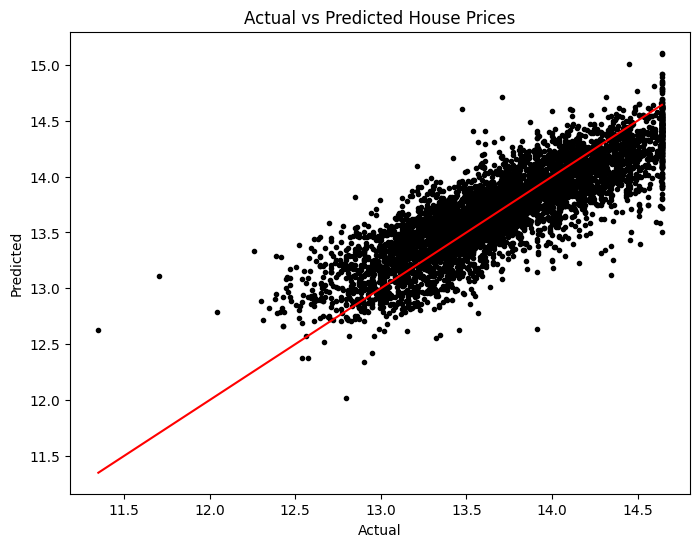

In [29]:
plt.figure(figsize = (8, 6))
plt.scatter(ytest, model.predict(xtest), marker = '.', color = 'black')
plt.plot(
    [ytest.min(), ytest.max()],
    [ytest.min(), ytest.max()],
    color='red'
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Residual Plot

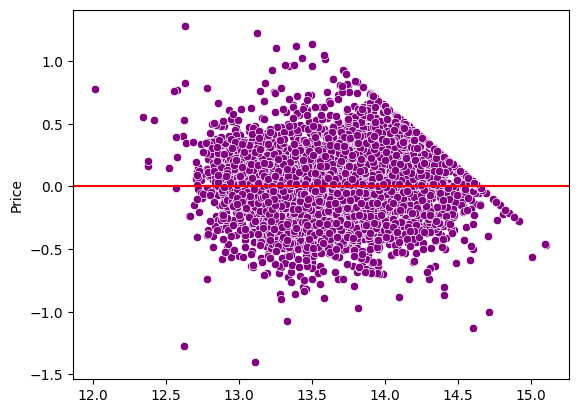

In [30]:
residuals = ytest - model.predict(xtest)

sns.scatterplot(
    x=model.predict(xtest),
    y=residuals,
    markers = '.',
    color = 'purple'
)

plt.axhline(0,color='red')

# Distribution of Residuals

<Axes: xlabel='Price', ylabel='Count'>

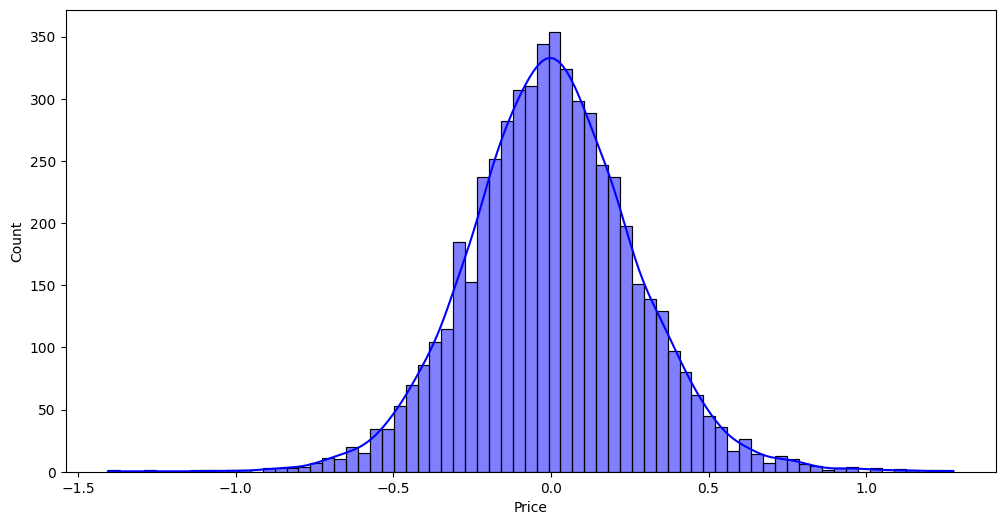

In [31]:
plt.figure(figsize = (12, 6))
sns.histplot(residuals, kde = True, color = 'b')

# kFold Cross Validation

In [32]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)
kf

KFold(n_splits=10, random_state=42, shuffle=True)

In [33]:
kf_scores = cross_val_score(
    model,
    x,
    y,
    cv=kf
)

print(kf_scores)
print(kf_scores.mean())

[0.71189106 0.71263539 0.68289316 0.72113702 0.67849691 0.69728279
 0.70725659 0.71616688 0.70726406 0.69168542]
0.7026709293951658


In [34]:
# joblib.dump(
#     model,
#     "linear_regression.joblib"
# )

In [35]:
# joblib.dump(
#     list(x.columns),
#     "feature_names.pkl"
# )

# Save Metrics

In [36]:
metrics = {
    "Train R2":r2_training_score,
    "Test R2":r2_testing_score,
    "MAE":mae,
    "MSE":mse,
    "RMSE":rmse,
    "Adjusted R²": adj_r2,
    "kf_scores":kf_scores.mean()
}

# Save Model

In [37]:
MODEL_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODEL_DIR / "linear_regression.pkl")
joblib.dump(list(x.columns), MODEL_DIR / "feature_names.pkl")

with open(MODEL_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

In [38]:
# # Save as JSON
# with open('metrics.json', 'w') as f:
#     json.dump(metrics, f, indent=4)